In [13]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.0 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [2]:
# 1. 데이터 로드 및 파생변수 생성 (이전과 동일)
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

def add_features(df):
    d = df.copy()
    # 단위 변환
    d["height_m"] = (d["Height(Feet)"] * 12 + d["Height(Remainder_Inches)"]) * 0.0254
    d["weight_kg"] = d["Weight(lb)"] * 0.453592

    # 파생변수
    d["bmi"] = d["weight_kg"] / d["height_m"] ** 2
    d["mhr"] = 220 - d["Age"]
    # 심박수 관련 (선형 관계를 돕기 위해)
    d["heart_reserve"] = (d["BPM"] - 60) / (d["mhr"] - 60)
    # 핵심 파생변수 (선형 회귀에 강력한 도움)
    d["metabolic_stress"] = d["BPM"] * d["Exercise_Duration"]
    d["thermal_load"] = ((d["Body_Temperature(F)"] - 32) * 5/9 - 37) * d["Exercise_Duration"]

    return d

In [3]:
# 2. 선형 회귀용 전처리 함수
def preprocess_for_linear(df):
    df = df.copy()

    # 불필요 컬럼 제거
    drop_cols = ["ID", "Height(Feet)", "Height(Remainder_Inches)", "Weight(lb)", "Body_Temperature(F)"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 범주형 변수 수동 매핑 (순서가 중요하므로)
    # Weight_Status: Normal < Overweight < Obese 순서로 매핑
    weight_map = {"Normal Weight": 0, "Overweight": 1, "Obese": 2}
    df["Weight_Status"] = df["Weight_Status"].map(weight_map)

    # Gender: F=0, M=1
    gender_map = {"F": 0, "M": 1}
    df["Gender"] = df["Gender"].map(gender_map)

    return df


In [4]:
# 3. 데이터 준비
train_fe = add_features(train)
test_fe = add_features(test)

train_lr = preprocess_for_linear(train_fe)
test_lr = preprocess_for_linear(test_fe)

X = train_lr.drop(columns=["Calories_Burned"])
y = train_lr["Calories_Burned"]

In [5]:
# 4. 스케일링 (선형회귀 필수!)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(test_lr), columns=X.columns)

In [6]:
# 5. 모델 학습 (Linear Regression)
# 다중공선성(변수 간 상관관계)이 높으므로 Ridge(L2 규제)도 같이 비교하면 좋으나, 일단 기본 LinearRegression 사용
model = LinearRegression()

In [7]:
# 교차 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_scaled, y, scoring="neg_root_mean_squared_error", cv=kf)
rmse_lr = -scores.mean()
print(f"==========================================")
print(f" 선형 회귀 (Linear Regression) 결과")
print(f"==========================================")
print(f"RMSE Score: {rmse_lr:.4f}")

 선형 회귀 (Linear Regression) 결과
RMSE Score: 6.9260


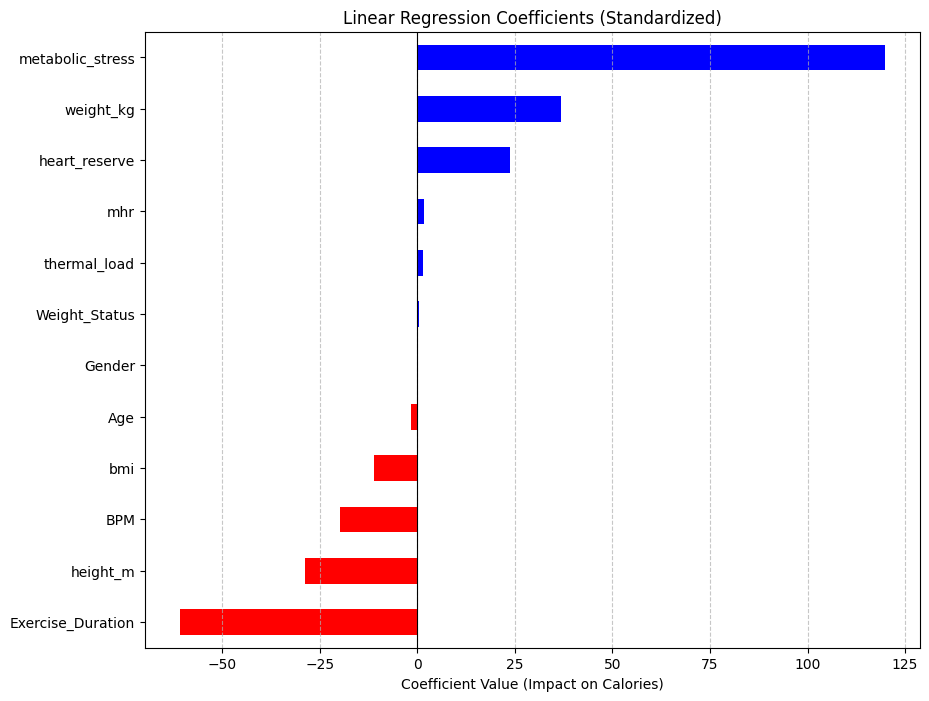

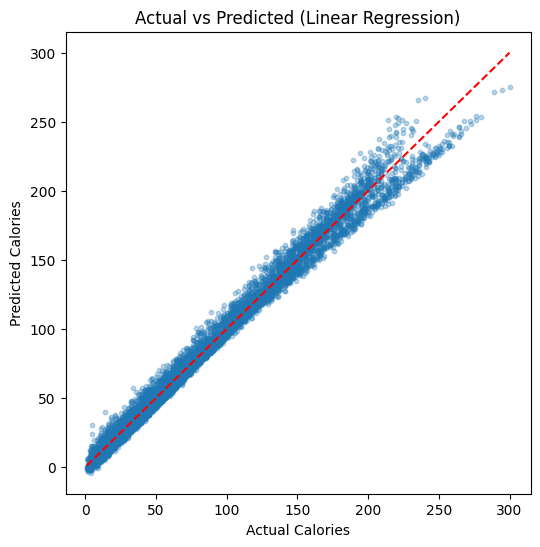

In [8]:
# 6. 회귀 계수(Coefficient) 시각화
model.fit(X_scaled, y)
coefs = pd.Series(model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'blue' for x in coefs]
coefs.plot(kind='barh', color=colors)
plt.title("Linear Regression Coefficients (Standardized)")
plt.xlabel("Coefficient Value (Impact on Calories)")
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 실제값 vs 예측값 시각화 (선형성이 얼마나 잘 맞는지 확인)
preds = model.predict(X_scaled)
plt.figure(figsize=(6, 6))
plt.scatter(y, preds, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Actual vs Predicted (Linear Regression)")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

 Linear vs Ridge (L2)
Linear RMSE : 6.9260
Ridge RMSE  : 6.9260
Best Alpha  : 0.001000


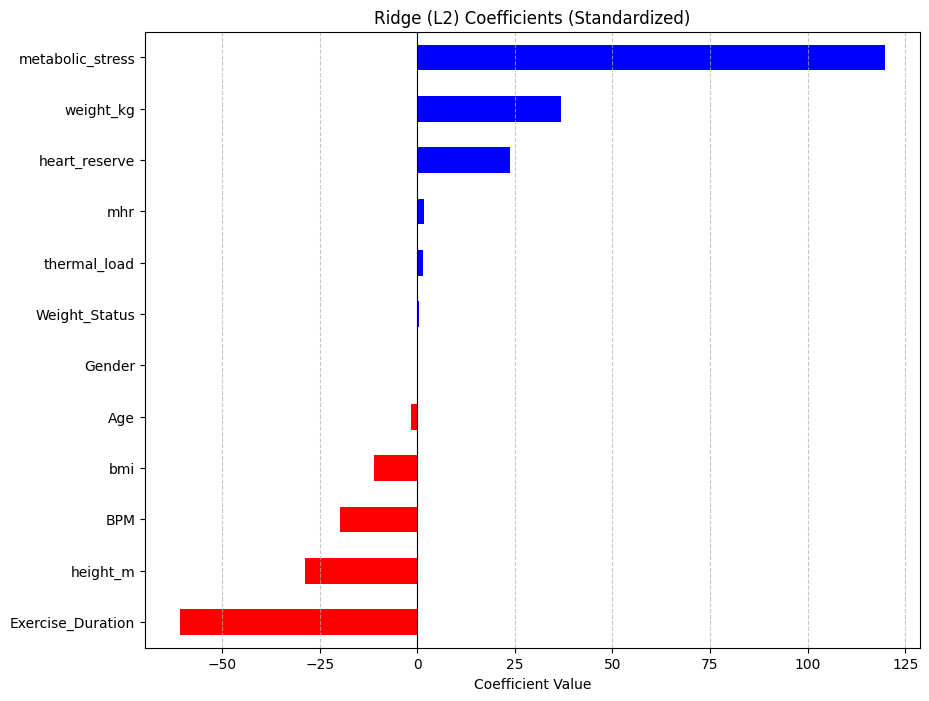

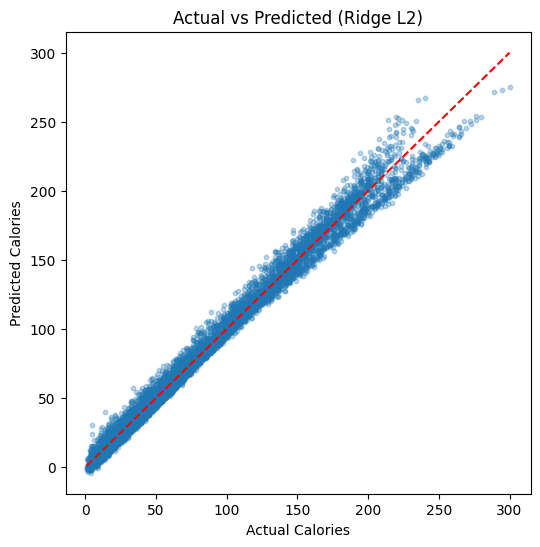

In [9]:
# ==========================================================
#  Linear vs Ridge (L2) 비교
# ==========================================================
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# ----- Linear Regression -----
lr_model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(
    lr_model, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)
rmse_lr = -lr_scores.mean()

# ----- Ridge (L2) -----
ridge = Ridge(random_state=42)

param_grid = {
    "alpha": np.logspace(-3, 3, 50)  # 0.001 ~ 1000
}

grid = GridSearchCV(
    ridge,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

grid.fit(X_scaled, y)

best_ridge = grid.best_estimator_
best_alpha = grid.best_params_["alpha"]
rmse_ridge = -grid.best_score_

print("==========================================")
print(" Linear vs Ridge (L2)")
print("==========================================")
print(f"Linear RMSE : {rmse_lr:.4f}")
print(f"Ridge RMSE  : {rmse_ridge:.4f}")
print(f"Best Alpha  : {best_alpha:.6f}")

# ==========================================================
#  Ridge 계수 시각화
# ==========================================================
best_ridge.fit(X_scaled, y)
coefs = pd.Series(best_ridge.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 8))
colors = ["red" if x < 0 else "blue" for x in coefs]
coefs.plot(kind="barh", color=colors)
plt.title("Ridge (L2) Coefficients (Standardized)")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# ==========================================================
#  실제값 vs 예측값 (Ridge)
# ==========================================================
preds_ridge = best_ridge.predict(X_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y, preds_ridge, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Actual vs Predicted (Ridge L2)")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()


 Polynomial + Ridge 결과
Best Alpha : 0.006723
RMSE Score : 1.6245


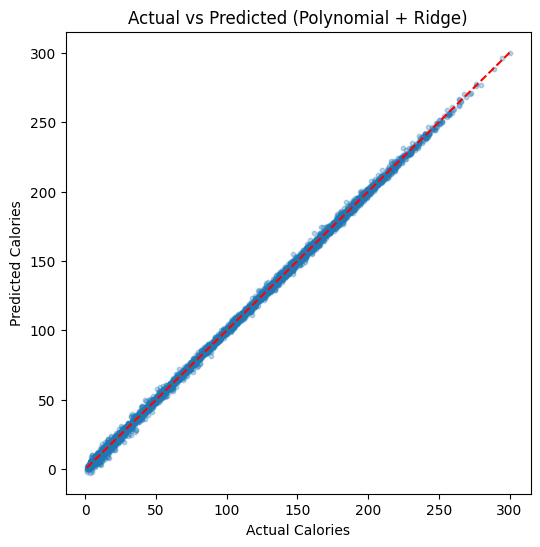

In [10]:
# ==========================================================
# Polynomial Regression + Ridge
# ==========================================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 파이프라인 구성
pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(random_state=42))
])

param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 30)
}

grid_poly = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

grid_poly.fit(X, y)

best_poly_model = grid_poly.best_estimator_
best_alpha_poly = grid_poly.best_params_["ridge__alpha"]
rmse_poly = -grid_poly.best_score_

print("==========================================")
print(" Polynomial + Ridge 결과")
print("==========================================")
print(f"Best Alpha : {best_alpha_poly:.6f}")
print(f"RMSE Score : {rmse_poly:.4f}")

# ==========================================================
# 실제값 vs 예측값 시각화
# ==========================================================
preds_poly = best_poly_model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, preds_poly, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Actual vs Predicted (Polynomial + Ridge)")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()


 SelectKBest + Poly + Ridge 결과
Best K       : 15
Best Alpha   : 0.008859
Best RMSE    : 1.6245


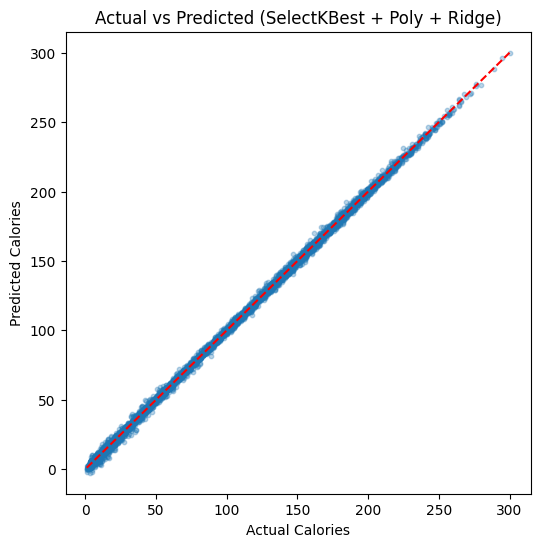

In [11]:
# ==========================================================
# SelectKBest + Polynomial + Ridge
# ==========================================================
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("select", SelectKBest(score_func=f_regression)),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(random_state=42))
])

param_grid = {
    "select__k": [10, 15, 20, 25, 30],
    "ridge__alpha": np.logspace(-3, 3, 20)
}

grid_select_poly = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

grid_select_poly.fit(X, y)

best_model = grid_select_poly.best_estimator_
best_k = grid_select_poly.best_params_["select__k"]
best_alpha = grid_select_poly.best_params_["ridge__alpha"]
rmse_best = -grid_select_poly.best_score_

print("==========================================")
print(" SelectKBest + Poly + Ridge 결과")
print("==========================================")
print(f"Best K       : {best_k}")
print(f"Best Alpha   : {best_alpha:.6f}")
print(f"Best RMSE    : {rmse_best:.4f}")

# ==========================================================
# 실제값 vs 예측값 시각화
# ==========================================================
preds_best = best_model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, preds_best, alpha=0.3, s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Actual vs Predicted (SelectKBest + Poly + Ridge)")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()


In [14]:
# ==========================================================
# Stacking Regressor
# ==========================================================
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Base models
ridge_base = Ridge(alpha=best_alpha, random_state=42)

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0
)

# Stacking
stack_model = StackingRegressor(
    estimators=[
        ("ridge", ridge_base),
        ("xgb", xgb_model),
        ("lgb", lgb_model),
        ("cat", cat_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

stack_scores = cross_val_score(
    stack_model,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

rmse_stack = -stack_scores.mean()

print("==========================================")
print(" Stacking Regressor 결과")
print("==========================================")
print(f"Stacking RMSE : {rmse_stack:.4f}")


 Stacking Regressor 결과
Stacking RMSE : 1.0945
